<a href="https://colab.research.google.com/github/hgkim-gnbeng/tunnel_fire_dynamics_book/blob/book_example/%EC%98%88%EC%A0%9C_4_9_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== 100m 지점 결과 ===
질량 유량: 172.80 kg/s
평균 가스 온도: 134.31 °C
평균 가스 속도: 2.78 m/s



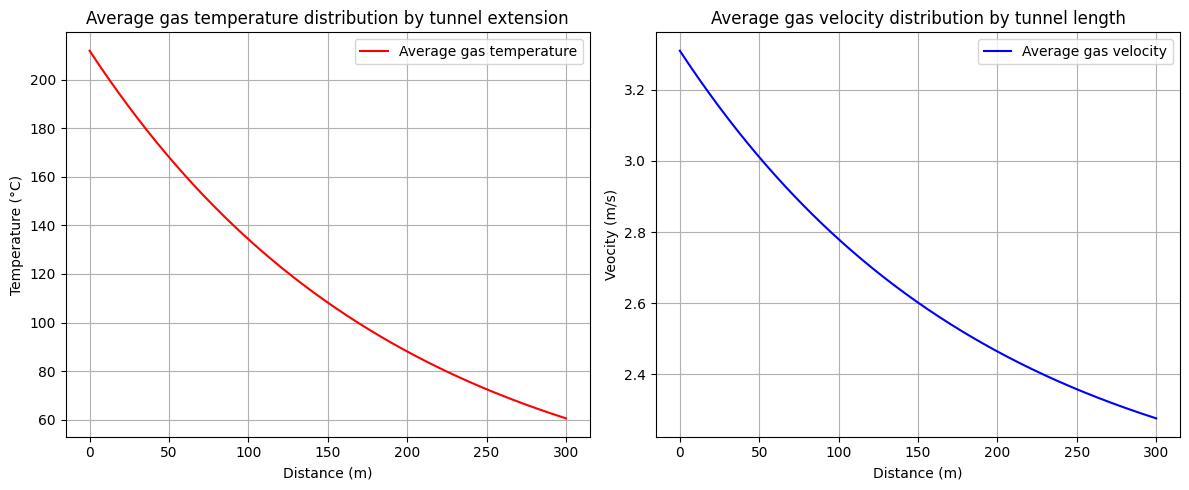

In [1]:
# <Python 코드작성(예)>

import numpy as np
import matplotlib.pyplot as plt

# 입력 파라미터
T_ambient = 20        # 외기온도 (°C)
H = 6                 # 터널 높이 (m)
W = 12                # 터널 폭 (m)
u_o = 2               # 환기 속도 (m/s)
Q = 50e6              # 화재 열방출률 (W)
cp = 1005             # 공기 비열 (J/kg·K)
rho_o = 1.2           # 공기 밀도 (kg/m³)
ht = 0.025 * 1000     # 총 열전달계수 (W/m²·K)

# 터널 단면 특성 계산
A_T = H * W            # 단면적 (m²)
w_p = 2 * (H + W)      # 습윤둘레 (m)

# 질량 유량 계산
m_dot = rho_o * u_o * A_T  # kg/s

# 거리 배열 (0~300m, 1m 간격)
x = np.linspace(0, 300, 301)

# 화원 위치 초기 온도 상승분
DeltaT_avg_0 = (2/3 * Q) / (m_dot * cp)

# 열손실 지수항 계산
exponent = -(ht * w_p * x) / (m_dot * cp)

# 거리별 온도 분포
DeltaT_avg_x = DeltaT_avg_0 * np.exp(exponent)
T_avg_x = T_ambient + DeltaT_avg_x

# 거리별 속도 분포 (이상기체 법칙 적용)
T_avg_x_K = T_avg_x + 273.15
T_ambient_K = T_ambient + 273.15
u_avg_x = u_o * T_avg_x_K / T_ambient_K

# 100m 지점 결과 출력
idx_100m = np.where(x == 100)[0][0]  # 100m 인덱스 찾기
print(f'''
=== 100m 지점 결과 ===
질량 유량: {m_dot:.2f} kg/s
평균 가스 온도: {T_avg_x[idx_100m]:.2f} °C
평균 가스 속도: {u_avg_x[idx_100m]:.2f} m/s
''')

# 그래프 출력
plt.figure(figsize=(12, 5))

# 온도 분포 그래프
plt.subplot(1, 2, 1)
plt.plot(x, T_avg_x, label='Average gas temperature', color='red')
plt.xlabel('Distance (m)')
plt.ylabel('Temperature (°C)')
plt.title('Average gas temperature distribution by tunnel extension')
plt.grid(True)
plt.legend()

# 속도 분포 그래프
plt.subplot(1, 2, 2)
plt.plot(x, u_avg_x, label='Average gas velocity', color='blue')
plt.xlabel('Distance (m)')
plt.ylabel('Veocity (m/s)')
plt.title('Average gas velocity distribution by tunnel length')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()